In [1]:
import functions as fn
from mastu import HSV
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import my_funcs as mf
import numpy as np
from pyEquilibrium.equilibrium import equilibrium as equil
import pyuda
client = pyuda.Client()
from scipy.interpolate import interp2d, RegularGridInterpolator
import sys

-------------------Loading module Divertor-------------------
-------------------Loading module Utilities-------------------
kk_cz couldnt be imported (SyntaxError)
dd couldnt be imported


In [2]:
%matplotlib widget

In [3]:
file = np.load('/home/sthoma/Documents/Results/rba/49091/testing_newRz.npz')

R = file['R']
data = file['data']
err = file['err']
time = file['time']
Rgrid = file['Rgrid']
RgridB = file['RgridB']
y = file['y']
yErr = file['yErr']
backprojection = file['backprojection']
scale = file['scale']

In [4]:
def mtanh(R, R0, height, width, grad, bkgd):
    ###
    z = -4. * (R - R0) / width
    L = 1. / (1. + np.exp(-z))
    profile = (L * (height - bkgd + ((z * width * grad) / 4.))) + bkgd
    return profile

In [5]:
shotn = 49091
twant = time[0]

psind = mf.find_nearest(RgridB, 1.)
eq = equil(device='mastu', shot=shotn, time=twant)
psiN = mf.getRho(shotn, twant, RgridB[psind:], 0.)[0][0]
sepR = np.interp(1., psiN, RgridB[psind:])

def forward(x):
    return np.interp(x, RgridB[psind:], psiN)
def inverse(x):
    return np.interp(x, psiN, RgridB[psind:])

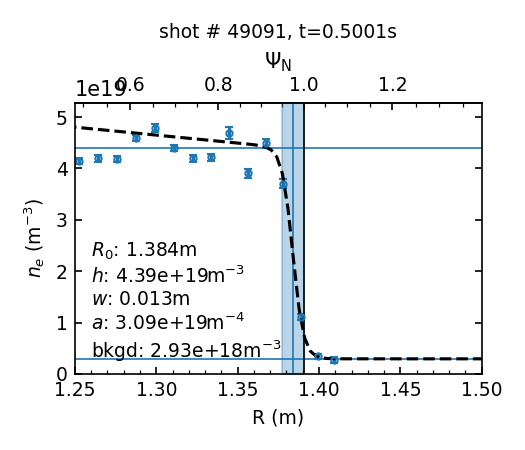

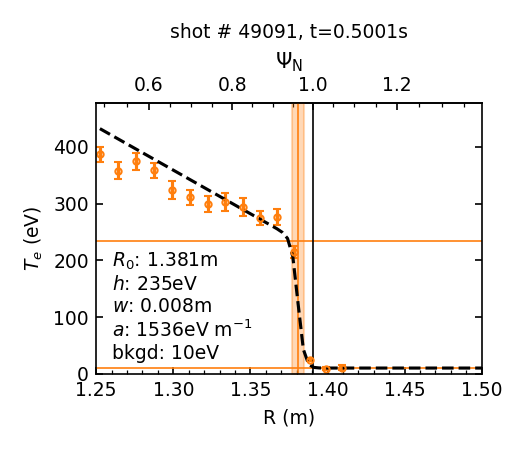

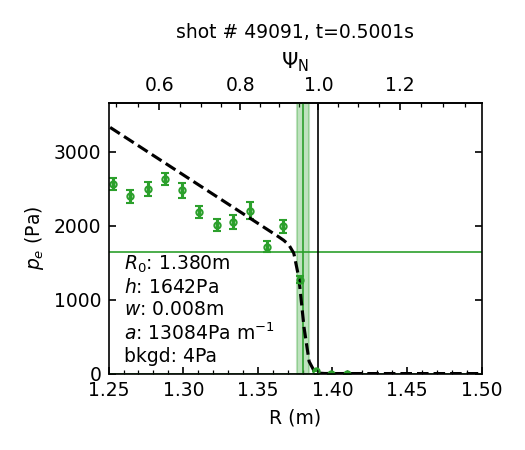

In [6]:
R0 = 1.25 # where the fit should be valid to
R1 = 1.50 # for the plots
y0 = 0.
yMult = 1.1 # for the ylim in the plots
dR = 0.01
dyDensity = 0.2e19
dyTemp = 20.
dyPressure = 100.


timePed = client.get('/apf/core/mtanh/lfs/time', shotn).data
tind = HSV.findNearest(timePed, twant)


R0Density = client.get('/apf/core/mtanh/lfs/n_e/pedestal_location', shotn).data[tind]
heightDensity = client.get('/apf/core/mtanh/lfs/n_e/pedestal_height', shotn).data[tind]
widthDensity = client.get('/apf/core/mtanh/lfs/n_e/pedestal_width', shotn).data[tind]
gradDensity = client.get('/apf/core/mtanh/lfs/n_e/pedestal_top_gradient', shotn).data[tind]
bkgdDensity = client.get('/apf/core/mtanh/lfs/n_e/background_level', shotn).data[tind]
paramsDensity = (
    R0Density, heightDensity, widthDensity, gradDensity, bkgdDensity
)
textDensity = f'\
$R_0$: {R0Density:.3f}m\n\
$h$: {heightDensity:.3g}m$^{{-3}}$\n\
$w$: {widthDensity:.3f}m\n\
$a$: {gradDensity:.3g}m$^{{-4}}$\n\
bkgd: {bkgdDensity:.3g}m$^{{-3}}$'

R0Temp = client.get('/apf/core/mtanh/lfs/T_e/pedestal_location', shotn).data[tind]
heightTemp = client.get('/apf/core/mtanh/lfs/T_e/pedestal_height', shotn).data[tind]
widthTemp = client.get('/apf/core/mtanh/lfs/T_e/pedestal_width', shotn).data[tind]
gradTemp = client.get('/apf/core/mtanh/lfs/T_e/pedestal_top_gradient', shotn).data[tind]
bkgdTemp = client.get('/apf/core/mtanh/lfs/T_e/background_level', shotn).data[tind]
paramsTemp = (
    R0Temp, heightTemp, widthTemp, gradTemp, bkgdTemp
)
textTemp = f'\
$R_0$: {R0Temp:.3f}m\n\
$h$: {heightTemp:.0f}eV\n\
$w$: {widthTemp:.3f}m\n\
$a$: {gradTemp:.0f}eV m$^{{-1}}$\n\
bkgd: {bkgdTemp:.0f}eV'

R0Pressure = client.get('/apf/core/mtanh/lfs/p_e/pedestal_location', shotn).data[tind]
heightPressure = client.get('/apf/core/mtanh/lfs/p_e/pedestal_height', shotn).data[tind]
widthPressure = client.get('/apf/core/mtanh/lfs/p_e/pedestal_width', shotn).data[tind]
gradPressure = client.get('/apf/core/mtanh/lfs/p_e/pedestal_top_gradient', shotn).data[tind]
bkgdPressure = client.get('/apf/core/mtanh/lfs/p_e/background_level', shotn).data[tind]
paramsPressure = (
    R0Pressure, heightPressure, widthPressure, gradPressure, bkgdPressure
)
textPressure = f'\
$R_0$: {R0Pressure:.3f}m\n\
$h$: {heightPressure:.0f}Pa\n\
$w$: {widthPressure:.3f}m\n\
$a$: {gradPressure:.0f}Pa m$^{{-1}}$\n\
bkgd: {bkgdPressure:.0f}Pa'


Rind = HSV.findNearest(RgridB, R0)
profileDensity = mtanh(RgridB, *paramsDensity)
y1Density = profileDensity[Rind] * yMult
profileTemp = mtanh(RgridB, *paramsTemp)
y1Temp = profileTemp[Rind] * yMult
profilePressure = mtanh(RgridB, *paramsPressure)
y1Pressure = profilePressure[Rind] * yMult


timeThomson = client.get('/ayc/time', shotn).data
tind0 = HSV.findNearest(timeThomson, twant)

ne, neErr, RThomson = mf.getNe(shotn)
ne = ne.data[tind0]
neErr = neErr[tind0]

Te, TeErr, _ = mf.getTe(shotn)
Te = Te.data[tind0]
TeErr = TeErr[tind0]

Pe, PeErr, _ = mf.getPe(shotn)
Pe = Pe.data[tind0]
PeErr = PeErr[tind0]

RThomson = RThomson[tind0]
indRTh = mf.find_nearest(RThomson, R0)


fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot([R0, R1], [heightDensity, heightDensity], '-', c='C0', lw=0.8)
ax.plot([R0, R1], [bkgdDensity, bkgdDensity], '-', c='C0', lw=0.8)
ax.plot([R0Density, R0Density], [y0, y1Density], '-', c='C0', lw=0.8)
ax.fill_between(
    [R0Density-widthDensity*0.5, R0Density+widthDensity*0.5], 
    [y0, y0], [y1Density, y1Density], color='C0', alpha=0.3, 
)
ax.errorbar(RThomson, ne, yerr=neErr, fmt='.', c='C0', mfc='None', capsize=2)
ax.plot(RgridB, profileDensity, '--k')
ax.set_xlim([R0, R1])
ax.set_ylim([y0, y1Density])
ax.set_xlabel('R (m)', fontsize=9)
ax.set_ylabel('$n_e$ (m$^{-3}$)', fontsize=9)
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=False
)
ax.xaxis.set_minor_locator(AutoMinorLocator())
secax = ax.secondary_xaxis('top', functions=(forward, inverse))
secax.xaxis.set_minor_locator(AutoMinorLocator())
secax.set_xlabel('$\\Psi_\\mathrm{N}$')
secax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=False, bottom=False, right=False, top=True
)
secax.minorticks_on()
ax.plot([sepR, sepR], [y0, y1Density], '-k', lw=0.8)
ax.set_title(f'shot # {shotn:.0f}, t={timePed[tind]:.4f}s', fontsize=9)
ax.text(R0+dR, y0+dyDensity, textDensity, ha='left', va='bottom', fontsize=9)
plt.tight_layout()


fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot([R0, R1], [heightTemp, heightTemp], '-', c='C1', lw=0.8)
ax.plot([R0, R1], [bkgdTemp, bkgdTemp], '-', c='C1', lw=0.8)
ax.plot([R0Temp, R0Temp], [y0, y1Temp], '-', c='C1', lw=0.8)
ax.fill_between(
    [R0Temp-widthTemp*0.5, R0Temp+widthTemp*0.5], 
    [y0, y0], [y1Temp, y1Temp], color='C1', alpha=0.3, 
)
ax.errorbar(RThomson, Te, yerr=TeErr, fmt='.', c='C1', mfc='None', capsize=2)
ax.plot(RgridB, profileTemp, '--k')
ax.set_xlim([R0, R1])
ax.set_ylim([y0, y1Temp])
ax.set_xlabel('R (m)', fontsize=9)
ax.set_ylabel('$T_e$ (eV)', fontsize=9)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=False
)
secax = ax.secondary_xaxis('top', functions=(forward, inverse))
secax.xaxis.set_minor_locator(AutoMinorLocator())
secax.set_xlabel('$\\Psi_\\mathrm{N}$')
secax.tick_params(axis="both", which='both', labelsize=9, direction='in', 
            left=False, bottom=False, right=False, top=True)
secax.minorticks_on()
ax.plot([sepR, sepR], [y0, y1Temp], '-k', lw=0.8)
ax.set_title(f'shot # {shotn:.0f}, t={timePed[tind]:.4f}s', fontsize=9)
ax.text(R0+dR, y0+dyTemp, textTemp, ha='left', va='bottom', fontsize=9)
plt.tight_layout()


fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot([R0, R1], [heightPressure, heightPressure], '-', c='C2', lw=0.8)
ax.plot([R0, R1], [bkgdPressure, bkgdPressure], '-', c='C2', lw=0.8)
ax.plot([R0Pressure, R0Pressure], [y0, y1Pressure], '-', c='C2', lw=0.8)
ax.fill_between(
    [R0Pressure-widthPressure*0.5, R0Pressure+widthPressure*0.5], 
    [y0, y0], [y1Pressure, y1Pressure], color='C2', alpha=0.3, 
)
ax.errorbar(RThomson, Pe, yerr=PeErr, fmt='.', c='C2', mfc='None', capsize=2)
ax.plot(RgridB, profilePressure, '--k')
ax.set_xlim([R0, R1])
ax.set_ylim([y0, y1Pressure])
ax.set_xlabel('R (m)', fontsize=9)
ax.set_ylabel('$p_e$ (Pa)', fontsize=9)
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=False
)
ax.xaxis.set_minor_locator(AutoMinorLocator())
secax = ax.secondary_xaxis('top', functions=(forward, inverse))
secax.xaxis.set_minor_locator(AutoMinorLocator())
secax.set_xlabel('$\\Psi_\\mathrm{N}$')
secax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=False, bottom=False, right=False, top=True
)
secax.minorticks_on()
ax.plot([sepR, sepR], [y0, y1Pressure], '-k', lw=0.8)
ax.set_title(f'shot # {shotn:.0f}, t={timePed[tind]:.4f}s', fontsize=9)
ax.text(R0+dR, y0+dyPressure, textPressure, ha='left', va='bottom', fontsize=9)
plt.tight_layout()

In [7]:
excit = np.load('/home/sthoma/tokamak_inversion_routines/ADAS/EXCIT_pec12#h_pju#h0.npz')
ne0 = excit['ne']#[13:20]
Te0 = excit['Te']#[4:23]
dataExcite = excit['data']#[13:20,4:23]
### units of [ph m^3 /s]
recom = np.load('/home/sthoma/tokamak_inversion_routines/ADAS/RECOM_pec12#h_pju#h0.npz')
dataRecomb = recom['data']#[13:20,4:23]
### units of [ph m^3 /s]
ionis = np.load('/home/sthoma/tokamak_inversion_routines/ADAS/IONIS_scd12h.npz')
dataIonise = ionis['data']#[13:20,4:23]
### units of [m^3 /s]

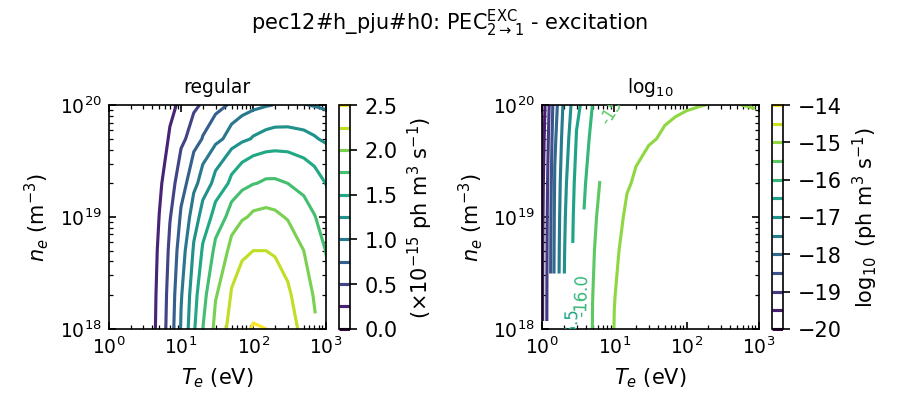

In [8]:
cmap=plt.cm.viridis

fig, ax = plt.subplots(1, 2, figsize=(6,2.75), dpi=150)


N = 15
levels = np.linspace(0., 2.5e-15*(10**N), 11)
cf = ax[0].contour(Te0, ne0, dataExcite*(10**N), levels, cmap=cmap)
fig.colorbar(
    cf, ax=ax[0], ticks=levels[::2], 
    label=f'($\\times10^{{{-N:.0f}}}$ ph m$^3$ s$^{{-1}}$)'
)
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].clabel(
    cf, inline=1, fontsize=8, fmt='%1.1f', inline_spacing=5, use_clabeltext=False
)
ax[0].set_xlabel('$T_e$ (eV)')
ax[0].set_ylabel('$n_e$ (m$^{-3}$)')
ax[0].set_xlim([1e0,1e3])
ax[0].set_ylim([1e18,1e20])
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].set_title('regular', fontsize=9)


levels = np.linspace(-20, -14, 13)
cf = ax[1].contour(Te0, ne0, np.log10(dataExcite), levels, cmap=cmap)
fig.colorbar(
    cf, ax=ax[1], ticks=levels[::2], 
    label='$\\log_{10}$ (ph m$^3$ s$^{-1}$)'
)
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].clabel(
    cf, inline=1, fontsize=8, fmt='%1.1f', inline_spacing=10, use_clabeltext=False
)
ax[1].set_xlabel('$T_e$ (eV)')
ax[1].set_ylabel('$n_e$ (m$^{-3}$)')
ax[1].set_xlim([1e0,1e3])
ax[1].set_ylim([1e18,1e20])
ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].set_title('$\\log_{10}$', fontsize=9)

fig.suptitle('pec12#h_pju#h0: PEC$^\\mathrm{EXC}_{2 \\rightarrow 1}$ - excitation', fontsize=10)
plt.tight_layout()

In [9]:
# ### excitation
# fExciteLinear = interp2d(Te0, ne0, dataExcite, kind='linear', bounds_error=True)
# fExciteCubic = interp2d(Te0, ne0, dataExcite, kind='cubic', bounds_error=True)

# exciteLinear = np.diag(fExciteLinear(profileTemp[Rind:], profileDensity[Rind:]))[::-1]
# exciteCubic = np.diag(fExciteCubic(profileTemp[Rind:], profileDensity[Rind:]))[::-1]


# fig, ax = plt.subplots(1, 1, figsize=(3.35,3), dpi=150)
# ax.plot(RgridB[Rind:], exciteLinear, 'o', c='C0', mfc='None', label='bi-linear')
# ax.plot(RgridB[Rind:], exciteCubic, '^', c='C1', mfc='None', label='bi-cubic')
# ax.set_title('PEC$^\\mathrm{EXC}_{2 \\rightarrow 1}$ - excitation', fontsize=9)
# ax.legend(fancybox=1, framealpha=1, fontsize=8)
# ax.set_xlabel('R (m)', fontsize=9)
# ax.set_ylabel('Interpolated values', fontsize=9)
# ax.tick_params(
#     axis="both", which='both', labelsize=9, direction='in', 
#     left=True, bottom=True, right=True, top=False
# )
# secax = ax.secondary_xaxis('top', functions=(forward, inverse))
# secax.xaxis.set_minor_locator(AutoMinorLocator())
# secax.set_xlabel('$\\Psi_\\mathrm{N}$')
# secax.tick_params(axis="both", which='both', labelsize=9, direction='in', 
#             left=False, bottom=False, right=False, top=True)
# secax.minorticks_on()
# ax.yaxis.get_offset_text().set_size(9)
# ax.set_xlim([R0, R1])
# plt.tight_layout()

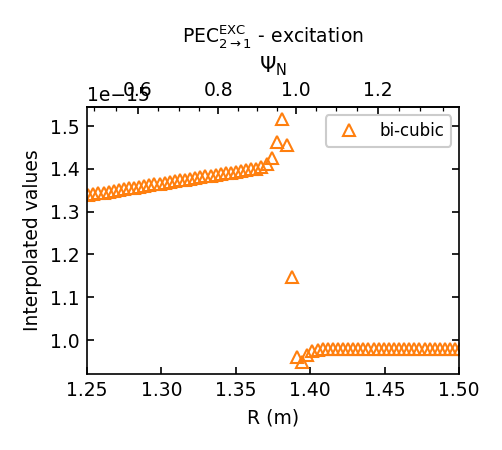

In [10]:
### excitation 
scaleExcite = 10**int(np.log10(np.median(dataExcite)))
fExcite = RegularGridInterpolator(
    (Te0, ne0), 
    dataExcite.T / scaleExcite, 
    method='cubic', 
)
exciteCubic = fExcite((profileTemp[Rind:], profileDensity[Rind:])) * scaleExcite

fig, ax = plt.subplots(1, 1, figsize=(3.35,3), dpi=150)
# ax.plot(RgridB[Rind:], exciteLinear, 'o', c='C0', mfc='None', label='bi-linear')
# ax.plot(RgridB[Rind:], outlinear, '-', c='C0', mfc='None', label='bi-linear2')
ax.plot(RgridB[Rind:], exciteCubic, '^', c='C1', mfc='None', label='bi-cubic')
# ax.plot(RgridB[Rind:], outcubic, '-', c='C1', mfc='None', label='bi-cubic2')
ax.set_title('PEC$^\\mathrm{EXC}_{2 \\rightarrow 1}$ - excitation', fontsize=9)
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.set_xlabel('R (m)', fontsize=9)
ax.set_ylabel('Interpolated values', fontsize=9)
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=False
)
secax = ax.secondary_xaxis('top', functions=(forward, inverse))
secax.xaxis.set_minor_locator(AutoMinorLocator())
secax.set_xlabel('$\\Psi_\\mathrm{N}$')
secax.tick_params(axis="both", which='both', labelsize=9, direction='in', 
            left=False, bottom=False, right=False, top=True)
secax.minorticks_on()
ax.yaxis.get_offset_text().set_size(9)
ax.set_xlim([R0, R1])
plt.tight_layout()

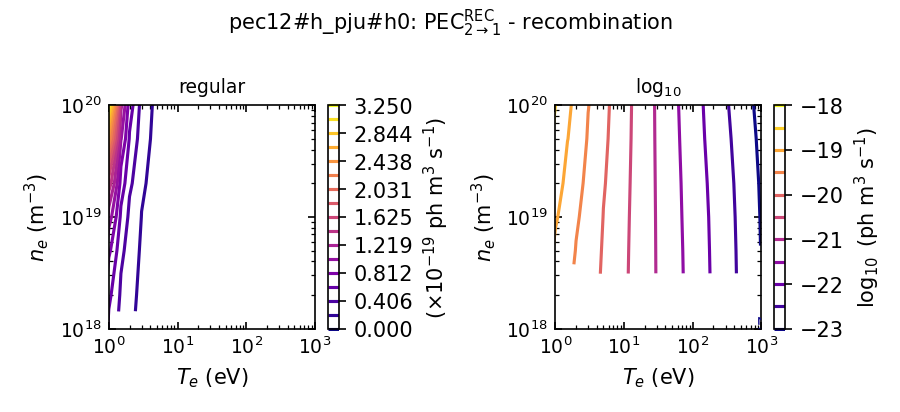

In [11]:
cmap=plt.cm.plasma

fig, ax = plt.subplots(1, 2, figsize=(6,2.75), dpi=150)


N = 19
levels = np.linspace(0., 3.25e-19*(10**N), 17)
cf = ax[0].contour(Te0, ne0, dataRecomb*(10**N), levels, cmap=cmap)
fig.colorbar(
    cf, ax=ax[0], ticks=levels[::2], 
    label=f'($\\times10^{{{-N:.0f}}}$ ph m$^3$ s$^{{-1}}$)'
)
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].clabel(
    cf, inline=1, fontsize=8, fmt='%1.1f', inline_spacing=5, use_clabeltext=False
)
ax[0].set_xlabel('$T_e$ (eV)')
ax[0].set_ylabel('$n_e$ (m$^{-3}$)')
ax[0].set_xlim([1e0,1e3])
ax[0].set_ylim([1e18,1e20])
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].set_title('regular', fontsize=9)


levels = np.linspace(-23, -18, 11)
cf = ax[1].contour(Te0, ne0, np.log10(dataRecomb), levels, cmap=cmap)
fig.colorbar(
    cf, ax=ax[1], ticks=levels[::2], 
    label='$\\log_{10}$ (ph m$^3$ s$^{-1}$)'
)
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].clabel(
    cf, inline=1, fontsize=8, fmt='%1.1f', inline_spacing=10, use_clabeltext=False
)
ax[1].set_xlabel('$T_e$ (eV)')
ax[1].set_ylabel('$n_e$ (m$^{-3}$)')
ax[1].set_xlim([1e0,1e3])
ax[1].set_ylim([1e18,1e20])
ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].set_title('$\\log_{10}$', fontsize=9)

fig.suptitle('pec12#h_pju#h0: PEC$^\\mathrm{REC}_{2 \\rightarrow 1}$ - recombination', fontsize=10)
plt.tight_layout()

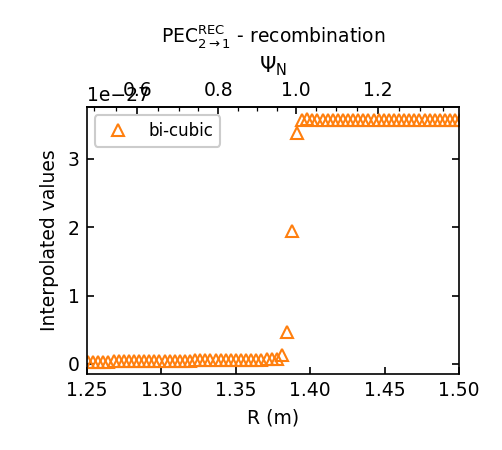

In [12]:
### recombination
# fRecombLinear = interp2d(Te0, ne0, dataRecomb, kind='linear', bounds_error=True)
# fRecombCubic = interp2d(Te0, ne0, dataRecomb, kind='cubic', bounds_error=True)

# recombLinear = np.diag(fRecombLinear(profileTemp[Rind:], profileDensity[Rind:]))[::-1]
# recombCubic = np.diag(fRecombCubic(profileTemp[Rind:], profileDensity[Rind:]))[::-1]
scaleRecomb = 10**int(np.log10(np.median(dataRecomb)))
fRecomb = RegularGridInterpolator(
    (Te0, ne0), 
    dataRecomb.T / scaleExcite, 
    method='cubic', 
)
recombCubic = fRecomb((profileTemp[Rind:], profileDensity[Rind:])) * scaleRecomb


fig, ax = plt.subplots(1, 1, figsize=(3.35,3), dpi=150)
# ax.plot(RgridB[Rind:], recombLinear, 'o', c='C0', mfc='None', label='bi-linear')
ax.plot(RgridB[Rind:], recombCubic, '^', c='C1', mfc='None', label='bi-cubic')
ax.set_title('PEC$^\\mathrm{REC}_{2 \\rightarrow 1}$ - recombination', fontsize=9)
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.set_xlabel('R (m)', fontsize=9)
ax.set_ylabel('Interpolated values', fontsize=9)
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=False
)
secax = ax.secondary_xaxis('top', functions=(forward, inverse))
secax.xaxis.set_minor_locator(AutoMinorLocator())
secax.set_xlabel('$\\Psi_\\mathrm{N}$')
secax.tick_params(axis="both", which='both', labelsize=9, direction='in', 
            left=False, bottom=False, right=False, top=True)
secax.minorticks_on()
ax.yaxis.get_offset_text().set_size(9)
ax.set_xlim([R0, R1])
plt.tight_layout()

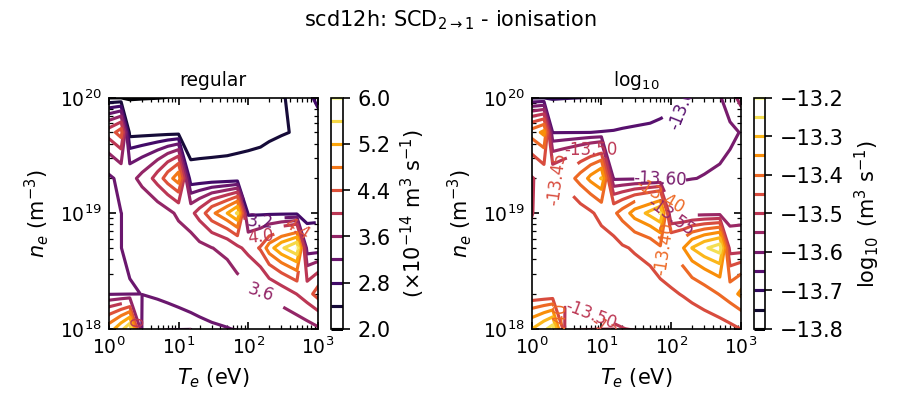

In [13]:
cmap=plt.cm.inferno

fig, ax = plt.subplots(1, 2, figsize=(6,2.75), dpi=150)


N = 14
levels = np.linspace(2e-14*(10**N), 6e-14*(10**N), 11)
cf = ax[0].contour(Te0, ne0, dataIonise*(10**N), levels, cmap=cmap)
fig.colorbar(
    cf, ax=ax[0], ticks=levels[::2], 
    label=f'($\\times10^{{{-N:.0f}}}$ m$^3$ s$^{{-1}}$)'
)
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].clabel(
    cf, inline=1, fontsize=8, fmt='%1.1f', inline_spacing=5, use_clabeltext=False
)
ax[0].set_xlabel('$T_e$ (eV)')
ax[0].set_ylabel('$n_e$ (m$^{-3}$)')
ax[0].set_xlim([1e0,1e3])
ax[0].set_ylim([1e18,1e20])
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].set_title('regular', fontsize=9)


levels = np.linspace(-13.8, -13.2, 13)
cf = ax[1].contour(Te0, ne0, np.log10(dataIonise), levels, cmap=cmap)
fig.colorbar(
    cf, ax=ax[1], ticks=levels[::2], 
    label='$\\log_{10}$ (m$^3$ s$^{-1}$)'
)
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xlim([1e0,1e3])
ax[1].set_ylim([1e18,1e20])
ax[1].clabel(
    cf, inline=1, fontsize=8, fmt='%1.2f', inline_spacing=5, use_clabeltext=False
)
ax[1].set_xlabel('$T_e$ (eV)')
ax[1].set_ylabel('$n_e$ (m$^{-3}$)')
ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].set_title('$\\log_{10}$', fontsize=9)

fig.suptitle('scd12h: SCD$_{2 \\rightarrow 1}$ - ionisation', fontsize=10)
plt.tight_layout()

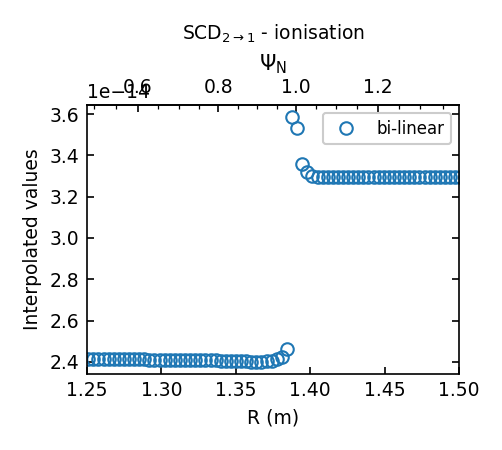

In [14]:
### ionisation
# fIoniseLinear = interp2d(Te0, ne0, dataIonise, kind='linear', bounds_error=True)
# fIoniseCubic = interp2d(Te0, ne0, dataIonise, kind='cubic', bounds_error=True)

# ioniseLinear = np.diag(fIoniseLinear(profileTemp[Rind:], profileDensity[Rind:]))[::-1]
# ioniseCubic = np.diag(fIoniseCubic(profileTemp[Rind:], profileDensity[Rind:]))[::-1]
scaleIonise = 10**int(np.log10(np.median(dataIonise)))
fIonise = RegularGridInterpolator(
    (Te0, ne0), 
    dataIonise.T / scaleIonise, 
    method='linear', 
)
ioniseLinear = fIonise((profileTemp[Rind:], profileDensity[Rind:])) * scaleIonise


fig, ax = plt.subplots(1, 1, figsize=(3.35,3), dpi=150)
ax.plot(RgridB[Rind:], ioniseLinear, 'o', c='C0', mfc='None', label='bi-linear')
# ax.plot(RgridB[Rind:], ioniseCubic, '^', c='C1', mfc='None', label='bi-cubic')
ax.set_title('SCD$_{2 \\rightarrow 1}$ - ionisation', fontsize=9)
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.set_xlabel('R (m)', fontsize=9)
ax.set_ylabel('Interpolated values', fontsize=9)
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=False
)
secax = ax.secondary_xaxis('top', functions=(forward, inverse))
secax.xaxis.set_minor_locator(AutoMinorLocator())
secax.set_xlabel('$\\Psi_\\mathrm{N}$')
secax.tick_params(axis="both", which='both', labelsize=9, direction='in', 
            left=False, bottom=False, right=False, top=True)
secax.minorticks_on()
ax.yaxis.get_offset_text().set_size(9)
ax.set_xlim([R0, R1])
plt.tight_layout()

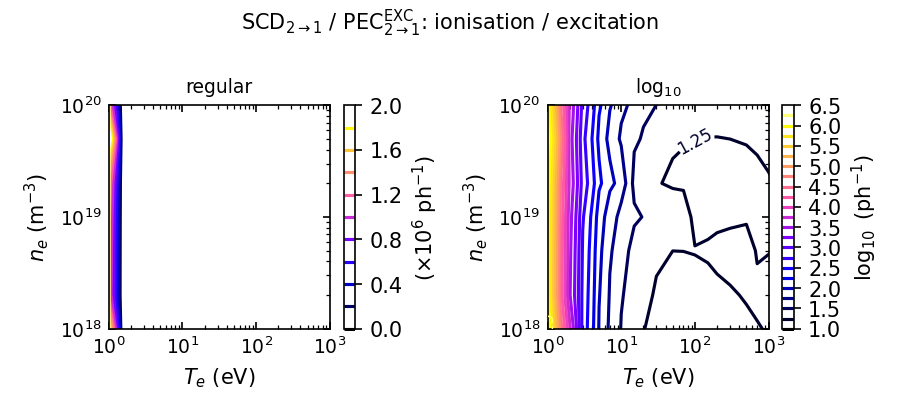

In [15]:
cmap=plt.cm.gnuplot2
Z = dataIonise / dataExcite

fig, ax = plt.subplots(1, 2, figsize=(6,2.75), dpi=150)


N = -6
levels = np.linspace(1e1*(10**N), 2e6*(10**N), 11)
cf = ax[0].contour(Te0, ne0, Z*(10**N), levels, cmap=cmap)
fig.colorbar(
    cf, ax=ax[0], ticks=levels[::2], 
    label=f'($\\times10^{{{-N:.0f}}}$ ph$^{{-1}}$)'
)
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].clabel(
    cf, inline=1, fontsize=8, fmt='%1.1f', inline_spacing=5, use_clabeltext=False
)
ax[0].set_xlabel('$T_e$ (eV)')
ax[0].set_ylabel('$n_e$ (m$^{-3}$)')
ax[0].set_xlim([1e0,1e3])
ax[0].set_ylim([1e18,1e20])
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].set_title('regular', fontsize=9)


levels = np.linspace(1., 6.5, 23)
cf = ax[1].contour(Te0, ne0, np.log10(Z), levels, cmap=cmap)
fig.colorbar(
    cf, ax=ax[1], ticks=levels[::2], 
    label='$\\log_{10}$ (ph$^{-1}$)'
)
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xlim([1e0,1e3])
ax[1].set_ylim([1e18,1e20])
ax[1].clabel(
    cf, inline=1, fontsize=8, fmt='%1.2f', inline_spacing=5, use_clabeltext=False
)
ax[1].set_xlabel('$T_e$ (eV)')
ax[1].set_ylabel('$n_e$ (m$^{-3}$)')
ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].set_title('$\\log_{10}$', fontsize=9)

fig.suptitle('SCD$_{2 \\rightarrow 1}$ / PEC$^\\mathrm{EXC}_{2 \\rightarrow 1}$: ionisation / excitation', fontsize=10)
plt.tight_layout()

/tmp/ipykernel_31869/1118945278.py:2: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, prefer `LinearNDInterpolator` or
`CloughTocher2DInterpolator`.

For more details see
`https://scipy.github.io/devdocs/notebooks/interp_transition_guide.html`

  fIonExcRatioLinear = interp2d(Te0, ne0, dataIonise/dataExcite, kind='linear', bounds_error=True)
/tmp/ipykernel_31869/1118945278.py:3: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For sc

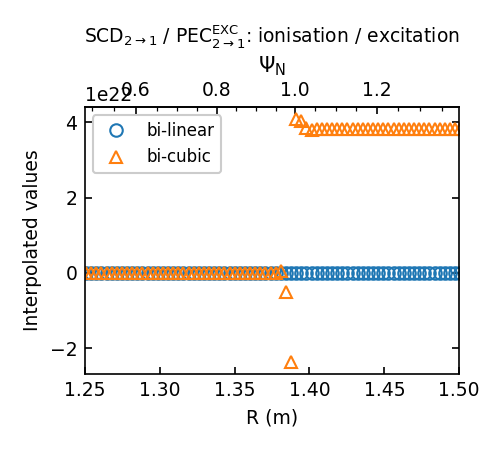

In [16]:
### ionisation
fIonExcRatioLinear = interp2d(Te0, ne0, dataIonise/dataExcite, kind='linear', bounds_error=True)
fIonExcRatioCubic = interp2d(Te0, ne0, dataIonise/dataExcite, kind='cubic', bounds_error=True)

ionExcLinear = np.diag(fIonExcRatioLinear(profileTemp[Rind:], profileDensity[Rind:]))[::-1]
ionExcCubic = np.diag(fIonExcRatioCubic(profileTemp[Rind:], profileDensity[Rind:]))[::-1]


fig, ax = plt.subplots(1, 1, figsize=(3.35,3), dpi=150)
ax.plot(RgridB[Rind:], ionExcLinear, 'o', c='C0', mfc='None', label='bi-linear')
ax.plot(RgridB[Rind:], ionExcCubic, '^', c='C1', mfc='None', label='bi-cubic')
ax.set_title('SCD$_{2 \\rightarrow 1}$ / PEC$^\\mathrm{EXC}_{2 \\rightarrow 1}$: ionisation / excitation', fontsize=9)
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.set_xlabel('R (m)', fontsize=9)
ax.set_ylabel('Interpolated values', fontsize=9)
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=False
)
secax = ax.secondary_xaxis('top', functions=(forward, inverse))
secax.xaxis.set_minor_locator(AutoMinorLocator())
secax.set_xlabel('$\\Psi_\\mathrm{N}$')
secax.tick_params(axis="both", which='both', labelsize=9, direction='in', 
            left=False, bottom=False, right=False, top=True)
secax.minorticks_on()
ax.yaxis.get_offset_text().set_size(9)
ax.set_xlim([R0, R1])
plt.tight_layout()

In [17]:
# def calcSiz(emissivity, temperature, density, fExcite, fIonise):
#     SCD = np.diag(fIonise(temperature, density))[::-1]
#     EXC = np.diag(fExcite(temperature, density))[::-1]
#     ionisation = 4. * np.pi * emissivity * SCD / EXC
#     return ionisation


# def calcN0(emissivity, temperature, density, fExcite, fRecomb):
#     REC = np.diag(fRecomb(temperature, density))[::-1] * density * density
#     EXC = np.diag(fExcite(temperature, density))[::-1] * density
#     n0 = ((4. * np.pi * emissivity) - REC) / EXC
#     return n0

def calcSiz(emissivity, temperature, density, fExcite, scaleExcite, fIonise, scaleIonise):
    SCD = fIonise((temperature, density)) * scaleIonise
    EXC = fExcite((temperature, density)) * scaleExcite
    ionisation = 4. * np.pi * emissivity * SCD / EXC
    return ionisation


def calcN0(emissivity, temperature, density, fExcite, scaleExcite, fRecomb, scaleRecomb):
    REC = fRecomb((temperature, density)) * scaleRecomb * density * density
    EXC = fExcite((temperature, density)) * scaleExcite * density
    n0 = ((4. * np.pi * emissivity) - REC) / EXC
    return n0

In [32]:
percentError = 0.10

# Siz = calcSiz(y[0][Rind:], profileTemp[Rind:], profileDensity[Rind:], fExcite, fIonise)
# n0 = calcN0(y[0][Rind:], profileTemp[Rind:], profileDensity[Rind:], fExcite, fRecombCubic)
Siz = calcSiz(y[0][Rind:], profileTemp[Rind:], profileDensity[Rind:], fExcite, scaleExcite, fIonise, scaleIonise)
n0 = calcN0(y[0][Rind:], profileTemp[Rind:], profileDensity[Rind:], fExcite, scaleExcite, fRecomb, scaleRecomb)

yLower = y[0] - yErr[0]
yUpper = y[0] + yErr[0]
SizErr = np.zeros((8,len(Siz)))
SizErr[0] = calcSiz(
    yLower[Rind:], (1.-percentError)*profileTemp[Rind:], 
    (1.-percentError)*profileDensity[Rind:], fExcite, scaleExcite, fIonise, scaleIonise
)
SizErr[1] = calcSiz(
    yLower[Rind:], (1.-percentError)*profileTemp[Rind:], 
    (1.+percentError)*profileDensity[Rind:], fExcite, scaleExcite, fIonise, scaleIonise
)
SizErr[2] = calcSiz(
    yLower[Rind:], (1.+percentError)*profileTemp[Rind:], 
    (1.-percentError)*profileDensity[Rind:], fExcite, scaleExcite, fIonise, scaleIonise
)
SizErr[3] = calcSiz(
    yLower[Rind:], (1.+percentError)*profileTemp[Rind:], 
    (1.+percentError)*profileDensity[Rind:], fExcite, scaleExcite, fIonise, scaleIonise
)
SizErr[4] = calcSiz(
    yUpper[Rind:], (1.-percentError)*profileTemp[Rind:], 
    (1.-percentError)*profileDensity[Rind:], fExcite, scaleExcite, fIonise, scaleIonise
)
SizErr[5] = calcSiz(
    yUpper[Rind:], (1.-percentError)*profileTemp[Rind:], 
    (1.+percentError)*profileDensity[Rind:], fExcite, scaleExcite, fIonise, scaleIonise
)
SizErr[6] = calcSiz(
    yUpper[Rind:], (1.+percentError)*profileTemp[Rind:], 
    (1.-percentError)*profileDensity[Rind:], fExcite, scaleExcite, fIonise, scaleIonise
)
SizErr[7] = calcSiz(
    yUpper[Rind:], (1.+percentError)*profileTemp[Rind:], 
    (1.+percentError)*profileDensity[Rind:], fExcite, scaleExcite, fIonise, scaleIonise
)
# SizUpper = SizErr.max(axis=0)
# SizLower = SizErr.min(axis=0)
SizUpper = Siz + np.abs(SizErr - Siz).max(axis=0)
SizLower = Siz - np.abs(SizErr - Siz).max(axis=0)


n0Err = np.zeros((8,len(n0)))
n0Err[0] = calcN0(
    yLower[Rind:], (1.-percentError)*profileTemp[Rind:], 
    (1.-percentError)*profileDensity[Rind:], fExcite, scaleExcite, fRecomb, scaleRecomb
)
n0Err[1] = calcN0(
    yLower[Rind:], (1.-percentError)*profileTemp[Rind:], 
    (1.+percentError)*profileDensity[Rind:], fExcite, scaleExcite, fRecomb, scaleRecomb
)
n0Err[2] = calcN0(
    yLower[Rind:], (1.+percentError)*profileTemp[Rind:], 
    (1.-percentError)*profileDensity[Rind:], fExcite, scaleExcite, fRecomb, scaleRecomb
)
n0Err[3] = calcN0(
    yLower[Rind:], (1.+percentError)*profileTemp[Rind:], 
    (1.+percentError)*profileDensity[Rind:], fExcite, scaleExcite, fRecomb, scaleRecomb
)
n0Err[4] = calcN0(
    yUpper[Rind:], (1.-percentError)*profileTemp[Rind:], 
    (1.-percentError)*profileDensity[Rind:], fExcite, scaleExcite, fRecomb, scaleRecomb
)
n0Err[5] = calcN0(
    yUpper[Rind:], (1.-percentError)*profileTemp[Rind:], 
    (1.+percentError)*profileDensity[Rind:], fExcite, scaleExcite, fRecomb, scaleRecomb
)
n0Err[6] = calcN0(
    yUpper[Rind:], (1.+percentError)*profileTemp[Rind:], 
    (1.-percentError)*profileDensity[Rind:], fExcite, scaleExcite, fRecomb, scaleRecomb
)
n0Err[7] = calcN0(
    yUpper[Rind:], (1.+percentError)*profileTemp[Rind:], 
    (1.+percentError)*profileDensity[Rind:], fExcite, scaleExcite, fRecomb, scaleRecomb
)
# n0Upper = n0Err.max(axis=0)
# n0Lower = n0Err.min(axis=0)
n0Upper = n0 + np.abs(n0Err - n0).max(axis=0)
n0Lower = n0 - np.abs(n0Err - n0).max(axis=0)

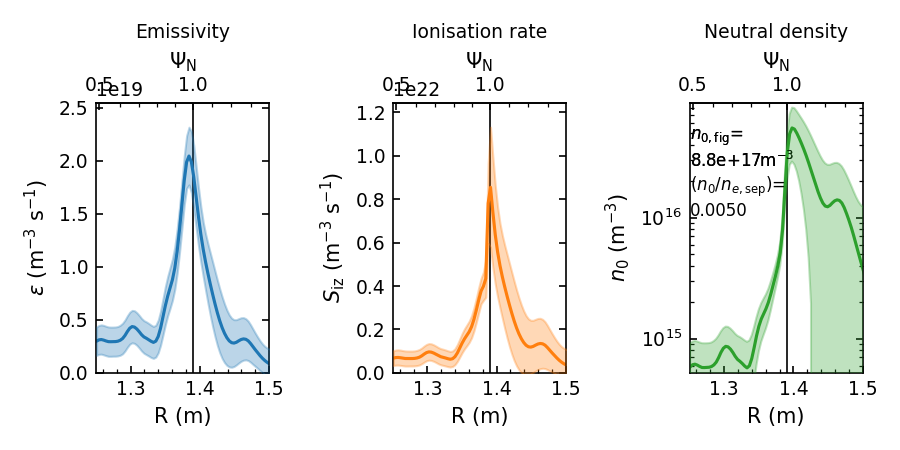

In [33]:
figPressure = HSV.calcFigPressure(shotn, twant, fig='mid')
figN0 = HSV.calcFigDensity(figPressure, T=300.)
densityRatioSep = (n0 / profileDensity[Rind:])[HSV.findNearest(psiN[Rind-psind:], 1.)]

R1 = 1.5
Rind1 = HSV.findNearest(RgridB[Rind:], R1)

fig, ax = plt.subplots(1, 3, figsize=(6,3), dpi=150)

ax[0].plot([sepR, sepR], [0., (y[0]+yErr[0]).max()*yMult], '-k', lw=0.8)
ax[0].plot(RgridB[Rind:], y[0][Rind:], '-', c='C0', mfc='None')
ax[0].fill_between(
    RgridB[Rind:], y[0][Rind:]-yErr[0][Rind:], 
    y[0][Rind:]+yErr[0][Rind:], color='C0', alpha=0.3, zorder=5
)
ax[0].set_title('Emissivity', fontsize=9)
ax[0].set_xlabel('R (m)')
ax[0].set_ylabel('$\\epsilon$ (m$^{-3}$ s$^{-1}$)')
ax[0].yaxis.get_offset_text().set_size(9)
ax[0].set_ylim([0., (y[0]+yErr[0]).max()*yMult])

ax[1].plot([sepR, sepR], [0., SizUpper.max()*yMult], '-k', lw=0.8)
ax[1].plot(RgridB[Rind:], Siz, '-', c='C1', mfc='None')
ax[1].fill_between(
    RgridB[Rind:], SizLower, SizUpper, color='C1', alpha=0.3, zorder=5
)
ax[1].set_title('Ionisation rate', fontsize=9)
ax[1].set_xlabel('R (m)')
ax[1].set_ylabel('$S_\\mathrm{iz}$ (m$^{-3}$ s$^{-1}$)')
ax[1].yaxis.get_offset_text().set_size(9)
ax[1].set_ylim([0., SizUpper.max()*yMult])

ax[2].plot([sepR, sepR], [0., n0Upper.max()*yMult], '-k', lw=0.8)
ax[2].plot(RgridB[Rind:], n0, '-', c='C2', mfc='None')
ax[2].fill_between(
    RgridB[Rind:], n0Lower, n0Upper, color='C2', alpha=0.3, zorder=5
)
ax[2].set_title('Neutral density', fontsize=9)
ax[2].set_xlabel('R (m)')
ax[2].set_ylabel('$n_0$ (m$^{-3}$)')
ax[2].yaxis.get_offset_text().set_size(9)
ax[2].set_ylim([n0[:Rind1].min()/yMult, n0Upper.max()*yMult])
ax[2].text(
    R0, n0.max(), 
    f'$n_{{0,\\mathrm{{fig}}}}$=\n{figN0:.2g}m$^{{-3}}$\n' + \
    f'$(n_0/n_{{e,\\mathrm{{sep}}}})$=\n{densityRatioSep:.4f}', 
    color='k', fontsize=8, va='top', ha='left'
)
ax[2].text(
    R0, n0.max(), 
    f'$n_{{0,\\mathrm{{fig}}}}$=\n{figN0:.2g}m$^{{-3}}$', 
    color='k', fontsize=8, va='top', ha='left'
)
ax[2].set_yscale('log')

for i in range(0, 3):
#     ax[i].plot([R0, R1], [0., 0.], '-k', lw=0.8)
    ax[i].set_xlim([R0, R1])
    ax[i].tick_params(
        axis="both", which='both', labelsize=9, direction='in', 
        left=True, bottom=True, right=True, top=False
    )
    ax[i].xaxis.set_minor_locator(AutoMinorLocator())
    secax = ax[i].secondary_xaxis('top', functions=(forward, inverse))
    secax.xaxis.set_minor_locator(AutoMinorLocator())
    secax.set_xlabel('$\\Psi_\\mathrm{N}$')
    secax.tick_params(
        axis="both", which='both', labelsize=9, direction='in', 
                left=False, bottom=False, right=False, top=True
    )
    secax.minorticks_on()

plt.tight_layout()

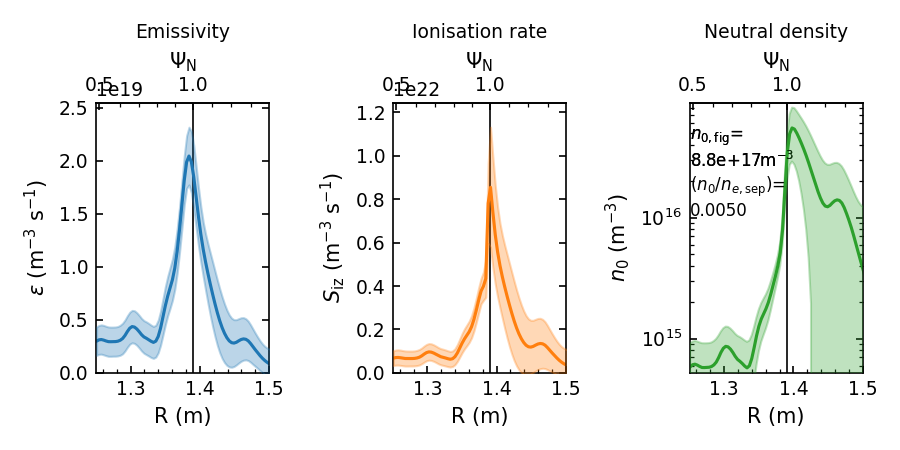

In [34]:
figPressure = HSV.calcFigPressure(shotn, twant, fig='mid')
figN0 = HSV.calcFigDensity(figPressure, T=300.)
densityRatioSep = (n0 / profileDensity[Rind:])[HSV.findNearest(psiN[Rind-psind:], 1.)]

R1 = 1.5
Rind1 = HSV.findNearest(RgridB[Rind:], R1)

fig, ax = plt.subplots(1, 3, figsize=(6,3), dpi=150)

ax[0].plot([sepR, sepR], [0., (y[0]+yErr[0]).max()*yMult], '-k', lw=0.8)
ax[0].plot(RgridB[Rind:], y[0][Rind:], '-', c='C0', mfc='None')
ax[0].fill_between(
    RgridB[Rind:], y[0][Rind:]-yErr[0][Rind:], 
    y[0][Rind:]+yErr[0][Rind:], color='C0', alpha=0.3, zorder=5
)
ax[0].set_title('Emissivity', fontsize=9)
ax[0].set_xlabel('R (m)')
ax[0].set_ylabel('$\\epsilon$ (m$^{-3}$ s$^{-1}$)')
ax[0].yaxis.get_offset_text().set_size(9)
ax[0].set_ylim([0., (y[0]+yErr[0]).max()*yMult])

ax[1].plot([sepR, sepR], [0., SizUpper.max()*yMult], '-k', lw=0.8)
ax[1].plot(RgridB[Rind:], Siz, '-', c='C1', mfc='None')
ax[1].fill_between(
    RgridB[Rind:], SizLower, SizUpper, color='C1', alpha=0.3, zorder=5
)
ax[1].set_title('Ionisation rate', fontsize=9)
ax[1].set_xlabel('R (m)')
ax[1].set_ylabel('$S_\\mathrm{iz}$ (m$^{-3}$ s$^{-1}$)')
ax[1].yaxis.get_offset_text().set_size(9)
ax[1].set_ylim([0., SizUpper.max()*yMult])

ax[2].plot([sepR, sepR], [0., n0Upper.max()*yMult], '-k', lw=0.8)
ax[2].plot(RgridB[Rind:], n0, '-', c='C2', mfc='None')
ax[2].fill_between(
    RgridB[Rind:], n0Lower, n0Upper, color='C2', alpha=0.3, zorder=5
)
ax[2].set_title('Neutral density', fontsize=9)
ax[2].set_xlabel('R (m)')
ax[2].set_ylabel('$n_0$ (m$^{-3}$)')
ax[2].yaxis.get_offset_text().set_size(9)
ax[2].set_ylim([n0[:Rind1].min()/yMult, n0Upper.max()*yMult])
ax[2].text(
    R0, n0.max(), 
    f'$n_{{0,\\mathrm{{fig}}}}$=\n{figN0:.2g}m$^{{-3}}$\n' + \
    f'$(n_0/n_{{e,\\mathrm{{sep}}}})$=\n{densityRatioSep:.4f}', 
    color='k', fontsize=8, va='top', ha='left'
)
ax[2].text(
    R0, n0.max(), 
    f'$n_{{0,\\mathrm{{fig}}}}$=\n{figN0:.2g}m$^{{-3}}$', 
    color='k', fontsize=8, va='top', ha='left'
)
ax[2].set_yscale('log')

for i in range(0, 3):
#     ax[i].plot([R0, R1], [0., 0.], '-k', lw=0.8)
    ax[i].set_xlim([R0, R1])
    ax[i].tick_params(
        axis="both", which='both', labelsize=9, direction='in', 
        left=True, bottom=True, right=True, top=False
    )
    ax[i].xaxis.set_minor_locator(AutoMinorLocator())
    secax = ax[i].secondary_xaxis('top', functions=(forward, inverse))
    secax.xaxis.set_minor_locator(AutoMinorLocator())
    secax.set_xlabel('$\\Psi_\\mathrm{N}$')
    secax.tick_params(
        axis="both", which='both', labelsize=9, direction='in', 
                left=False, bottom=False, right=False, top=True
    )
    secax.minorticks_on()

plt.tight_layout()

In [20]:
# HSV.getRz('/home/sthoma/tokamak_inversion_routines/mastu/rba_viewing_49091.npz', )

In [39]:
print(n0)

[ 5.85420246e+14  6.09047879e+14  6.15516466e+14  6.05114575e+14
  5.89708454e+14  5.77921359e+14  5.77113852e+14  5.78948322e+14
  5.80667189e+14  5.88499495e+14  6.06826912e+14  6.39808884e+14
  6.96732180e+14  7.70700187e+14  8.33063935e+14  8.64230249e+14
  8.55677676e+14  8.20395338e+14  7.70243845e+14  7.14936181e+14
  6.73719083e+14  6.49879962e+14  6.23312086e+14  5.94276172e+14
  5.73851122e+14  5.97771975e+14  6.85641696e+14  8.43168872e+14
  1.05231615e+15  1.26742173e+15  1.45273339e+15  1.60704133e+15
  1.76868383e+15  1.99294604e+15  2.32326487e+15  2.75579431e+15
  3.29543579e+15  3.99935544e+15  5.11147127e+15  7.97623642e+15
  1.72182339e+16  3.46724232e+16  4.93689726e+16  5.50941315e+16
  5.39050292e+16  4.99344876e+16  4.54154299e+16  4.09056283e+16
  3.65540563e+16  3.23765674e+16  2.84032995e+16  2.47224771e+16
  2.14487068e+16  1.86395272e+16  1.63264262e+16  1.45032698e+16
  1.31909866e+16  1.24624854e+16  1.23021799e+16  1.26315317e+16
  1.32392069e+16  1.37742

In [37]:
"6.79010882e+20 7.04750744e+20 7.10554163e+20 6.96894140e+20 6.77542449e+20 6.62424090e+20 6.59926145e+20 6.60447561e+20 6.60828498e+20 6.68141932e+20 6.87300780e+20 7.22919338e+20 7.85346328e+20 8.66632101e+20 9.34501000e+20 9.67121832e+20 9.55235296e+20 9.13629098e+20 8.55696376e+20 7.92321744e+20 7.44824772e+20 7.16716637e+20 6.85736150e+20 6.52191338e+20 6.28230735e+20 6.52809884e+20 7.46864266e+20 9.15990662e+20 1.14012227e+21 1.36945651e+21 1.56537457e+21 1.72671318e+21 1.89444114e+21 2.12627276e+21 2.46344067e+21 2.88585572e+21 3.34907168e+21 3.76542025e+21 3.99090214e+21 4.34304055e+21 7.81233902e+21 8.55004578e+21 7.39230625e+21 6.36424758e+21 5.56543228e+21 4.93805643e+21 4.42125078e+21 3.95998395e+21 3.53170715e+21 3.12590394e+21 2.74161334e+21 2.38611559e+21 2.07008041e+21 1.79893823e+21 1.57569007e+21 1.39973231e+21 1.27308125e+21 1.20277238e+21 1.18730107e+21 1.21908739e+21 1.27773515e+21 1.32937729e+21 1.35407517e+21 1.33841809e+21 1.27672162e+21 1.16935283e+21 1.04250068e+21 9.19327174e+20 8.00344303e+20 6.85347431e+20 5.81001763e+20 4.91967268e+20 4.18428940e+20 3.57929867e+20 3.04440902e+20 2.51308600e+20 2.02104341e+20 1.61209016e+20 1.28667765e+20 1.03646353e+20 8.51648102e+19 7.23665639e+19 6.36504540e+19 5.71283899e+19 5.14504002e+19 4.63575389e+19 4.19631992e+19 3.82030078e+19 3.49914156e+19 3.22499220e+19 2.99114453e+19 2.79198967e+19 2.62286705e+19 2.47990337e+19 2.35986822e+19 2.26005185e+19 2.17816395e+19 2.11225061e+19 2.06062644e+19 2.02181931e+19 1.99452544e+19 1.97757327e+19 1.96989443e+19 1.97050083e+19 1.97846682e+19 1.99291549e+19 2.01300852e+19 2.03793890e+19 2.06692593e+19 2.09921221e+19 2.13406199e+19 2.17076078e+19 2.20861582e+19 2.24695719e+19 2.28513946e+19 2.32254353e+19 2.35857879e+19 2.39268524e+19 2.42433561e+19 2.45303738e+19 2.47833463e+19 2.49980974e+19 2.51708472e+19 2.52982238e+19 2.53772716e+19 2.54054567e+19 2.53806690e+19 2.53012212e+19 2.51658453e+19 2.49736850e+19 2.47242866e+19 2.44175856e+19 2.40538923e+19 2.36338737e+19 2.31585337e+19 2.26291916e+19 2.20474581e+19 2.14152100e+19 2.07345638e+19 2.00078476e+19 1.92375727e+19 1.84264037e+19 1.75771284e+19 1.66926279e+19 1.57758458e+19 1.48297573e+19 1.38573396e+19 1.28615414e+19 1.18452537e+19 1.08112808e+19 9.76231223e+18 8.70089521e+18 7.62940830e+18 6.55003573e+18 5.46474269e+18 4.37525159e+18 3.28301919e+18 2.18921457e+18 1.09469793e+18 5.63773907e+09 5.58375077e+09"
"6.79010955e+20 7.04750801e+20 7.10554195e+20 6.96894143e+20 6.77542426e+20 6.62424047e+20 6.59926087e+20 6.60447492e+20 6.60828421e+20 6.68141850e+20 6.87300695e+20 7.22919250e+20 7.85346227e+20 8.66631977e+20 9.34500864e+20 9.67121707e+20 9.55235202e+20 9.13629037e+20 8.55696342e+20 7.92321731e+20 7.44824762e+20 7.16716617e+20 6.85736132e+20 6.52191349e+20 6.28230799e+20 6.52809987e+20 7.46864370e+20 9.15990738e+20 1.14012231e+21 1.36945655e+21 1.56537462e+21 1.72671326e+21 1.89444121e+21 2.12627280e+21 2.46344065e+21 2.88585562e+21 3.34907150e+21 3.76542000e+21 3.99090188e+21 4.34304032e+21 7.81233880e+21 8.55004578e+21 7.39230645e+21 6.36424790e+21 5.56543264e+21 4.93805677e+21 4.42125107e+21 3.95998420e+21 3.53170739e+21 3.12590420e+21 2.74161366e+21 2.38611597e+21 2.07008085e+21 1.79893873e+21 1.57569060e+21 1.39973284e+21 1.27308177e+21 1.20277284e+21 1.18730144e+21 1.21908764e+21 1.27773526e+21 1.32937726e+21 1.35407503e+21 1.33841786e+21 1.27672134e+21 1.16935252e+21 1.04250036e+21 9.19326853e+20 8.00343987e+20 6.85347130e+20 5.81001484e+20 4.91967014e+20 4.18428712e+20 3.57929664e+20 3.04440719e+20 2.51308429e+20 2.02104172e+20 1.61208844e+20 1.28667586e+20 1.03646169e+20 8.51646237e+19 7.23663804e+19 6.36502789e+19 5.71282262e+19 5.14502480e+19 4.63573982e+19 4.19630709e+19 3.82028930e+19 3.49913156e+19 3.22498377e+19 2.99113777e+19 2.79198463e+19 2.62286377e+19 2.47990187e+19 2.35986851e+19 2.26005389e+19 2.17816770e+19 2.11225602e+19 2.06063343e+19 2.02182779e+19 1.99453531e+19 1.97758441e+19 1.96990672e+19 1.97051415e+19 1.97848103e+19 1.99293046e+19 2.01302412e+19 2.03795500e+19 2.06694240e+19 2.09922892e+19 2.13407883e+19 2.17077763e+19 2.20863257e+19 2.24697375e+19 2.28515572e+19 2.32255942e+19 2.35859423e+19 2.39270017e+19 2.42434997e+19 2.45305111e+19 2.47834771e+19 2.49982213e+19 2.51709640e+19 2.52983333e+19 2.53773738e+19 2.54055515e+19 2.53807564e+19 2.53013015e+19 2.51659185e+19 2.49737514e+19 2.47243464e+19 2.44176392e+19 2.40539399e+19 2.36339157e+19 2.31585705e+19 2.26292235e+19 2.20474855e+19 2.14152332e+19 2.07345833e+19 2.00078638e+19 1.92375859e+19 1.84264142e+19 1.75771367e+19 1.66926343e+19 1.57758505e+19 1.48297606e+19 1.38573418e+19 1.28615427e+19 1.18452543e+19 1.08112809e+19 9.76231201e+18 8.70089476e+18 7.62940774e+18 6.55003513e+18 5.46474213e+18 4.37525110e+18 3.28301881e+18 2.18921431e+18 1.09469780e+18 5.63776701e+09 5.58377844e+09"

False

In [ ]:
[6.79010882e+20 7.04750744e+20 7.10554163e+20 6.96894140e+20
 6.77542449e+20 6.62424090e+20 6.59926145e+20 6.60447561e+20
 6.60828498e+20 6.68141932e+20 6.87300780e+20 7.22919338e+20
 7.85346328e+20 8.66632101e+20 9.34501000e+20 9.67121832e+20
 9.55235296e+20 9.13629098e+20 8.55696376e+20 7.92321744e+20
 7.44824772e+20 7.16716637e+20 6.85736150e+20 6.52191338e+20
 6.28230735e+20 6.52809884e+20 7.46864266e+20 9.15990662e+20
 1.14012227e+21 1.36945651e+21 1.56537457e+21 1.72671318e+21
 1.89444114e+21 2.12627276e+21 2.46344067e+21 2.88585572e+21
 3.34907168e+21 3.76542025e+21 3.99090214e+21 4.34304055e+21
 7.81233902e+21 8.55004578e+21 7.39230625e+21 6.36424758e+21
 5.56543228e+21 4.93805643e+21 4.42125078e+21 3.95998395e+21
 3.53170715e+21 3.12590394e+21 2.74161334e+21 2.38611559e+21
 2.07008041e+21 1.79893823e+21 1.57569007e+21 1.39973231e+21
 1.27308125e+21 1.20277238e+21 1.18730107e+21 1.21908739e+21
 1.27773515e+21 1.32937729e+21 1.35407517e+21 1.33841809e+21
 1.27672162e+21 1.16935283e+21 1.04250068e+21 9.19327174e+20
 8.00344303e+20 6.85347431e+20 5.81001763e+20 4.91967268e+20
 4.18428940e+20 3.57929867e+20 3.04440902e+20 2.51308600e+20
 2.02104341e+20 1.61209016e+20 1.28667765e+20 1.03646353e+20
 8.51648102e+19 7.23665639e+19 6.36504540e+19 5.71283899e+19
 5.14504002e+19 4.63575389e+19 4.19631992e+19 3.82030078e+19
 3.49914156e+19 3.22499220e+19 2.99114453e+19 2.79198967e+19
 2.62286705e+19 2.47990337e+19 2.35986822e+19 2.26005185e+19
 2.17816395e+19 2.11225061e+19 2.06062644e+19 2.02181931e+19
 1.99452544e+19 1.97757327e+19 1.96989443e+19 1.97050083e+19
 1.97846682e+19 1.99291549e+19 2.01300852e+19 2.03793890e+19
 2.06692593e+19 2.09921221e+19 2.13406199e+19 2.17076078e+19
 2.20861582e+19 2.24695719e+19 2.28513946e+19 2.32254353e+19
 2.35857879e+19 2.39268524e+19 2.42433561e+19 2.45303738e+19
 2.47833463e+19 2.49980974e+19 2.51708472e+19 2.52982238e+19
 2.53772716e+19 2.54054567e+19 2.53806690e+19 2.53012212e+19
 2.51658453e+19 2.49736850e+19 2.47242866e+19 2.44175856e+19
 2.40538923e+19 2.36338737e+19 2.31585337e+19 2.26291916e+19
 2.20474581e+19 2.14152100e+19 2.07345638e+19 2.00078476e+19
 1.92375727e+19 1.84264037e+19 1.75771284e+19 1.66926279e+19
 1.57758458e+19 1.48297573e+19 1.38573396e+19 1.28615414e+19
 1.18452537e+19 1.08112808e+19 9.76231223e+18 8.70089521e+18
 7.62940830e+18 6.55003573e+18 5.46474269e+18 4.37525159e+18
 3.28301919e+18 2.18921457e+18 1.09469793e+18 5.63773907e+09
 5.58375077e+09]
[ 5.84277665e+14  6.07880970e+14  6.14325116e+14  6.03898668e+14
  5.88467872e+14  5.76655984e+14  5.75823564e+14  5.77633009e+14
  5.79326739e+14  5.87133797e+14  6.05435861e+14  6.38392376e+14
  6.95290125e+14  7.69232495e+14  8.31570501e+14  8.62710959e+14
  8.54132420e+14  8.18824025e+14  7.68646394e+14  7.13312513e+14
  6.72069132e+14  6.48203662e+14  6.21609346e+14  5.92546894e+14
  5.72095210e+14  5.95989374e+14  6.83832371e+14  8.41332810e+14
  1.05045336e+15  1.26553227e+15  1.45081744e+15  1.60509929e+15
  1.76671673e+15  1.99095638e+15  2.32125901e+15  2.75378732e+15
  3.29345624e+15  3.99743485e+15  5.10868492e+15  7.96918405e+15
  1.71968716e+16  3.46478241e+16  4.93521926e+16  5.50812203e+16
  5.38935665e+16  4.99235449e+16  4.54046723e+16  4.08949365e+16
  3.65433877e+16  3.23659068e+16  2.83926412e+16  2.47118191e+16
  2.14380486e+16  1.86288686e+16  1.63157672e+16  1.44926108e+16
  1.31803278e+16  1.24518272e+16  1.22915226e+16  1.26208757e+16
  1.32285524e+16  1.37636405e+16  1.40195467e+16  1.38573165e+16
  1.32180508e+16  1.21055529e+16  1.07911791e+16  9.51492131e+15
  8.28208467e+15  7.09054880e+15  6.00937499e+15  5.08684734e+15
  4.32488265e+15  3.69802373e+15  3.14379978e+15  2.59327139e+15
  2.08344326e+15  1.65970786e+15  1.32253288e+15  1.06327444e+15
  8.71778604e+14  7.39170044e+14  6.48858391e+14  5.81280264e+14
  5.22447981e+14  4.69678487e+14  4.24146697e+14  3.85185612e+14
  3.51908817e+14  3.23502931e+14  2.99272892e+14  2.78637534e+14
  2.61113956e+14  2.46300826e+14  2.33863428e+14  2.23520992e+14
  2.15036207e+14  2.08206620e+14  2.02857601e+14  1.98836614e+14
  1.96008571e+14  1.94252078e+14  1.93456437e+14  1.93519269e+14
  1.94344662e+14  1.95841756e+14  1.97923688e+14  2.00506839e+14
  2.03510320e+14  2.06855651e+14  2.10466599e+14  2.14269130e+14
  2.18191466e+14  2.22164194e+14  2.26120435e+14  2.29996044e+14
  2.33729824e+14  2.37263752e+14  2.40543193e+14  2.43517116e+14
  2.46138282e+14  2.48363418e+14  2.50153358e+14  2.51473166e+14
  2.52292217e+14  2.52584256e+14  2.52327419e+14  2.51504224e+14
  2.50101531e+14  2.48110470e+14  2.45526337e+14  2.42348466e+14
  2.38580071e+14  2.34228063e+14  2.29302846e+14  2.23818087e+14
  2.17790477e+14  2.11239461e+14  2.04186970e+14  1.96657128e+14
  1.88675952e+14  1.80271054e+14  1.71471319e+14  1.62306600e+14
  1.52807396e+14  1.43004534e+14  1.32928864e+14  1.22610938e+14
  1.12080710e+14  1.01367238e+14  9.04983886e+13  7.95005551e+13
  6.83983828e+13  5.72145035e+13  4.59692795e+13  3.46805575e+13
  2.33634315e+13  1.20300152e+13  6.89221145e+11 -1.06534512e+13
 -1.06534512e+13]

In [ ]:
5.85420246e+14  6.09047879e+14  6.15516466e+14  6.05114575e+14  5.89708454e+14  5.77921359e+14  5.77113852e+14  5.78948322e+14  5.80667189e+14  5.88499495e+14  6.06826912e+14  6.39808884e+14  6.96732180e+14  7.70700187e+14  8.33063935e+14  8.64230249e+14  8.55677676e+14  8.20395338e+14  7.70243845e+14  7.14936181e+14  6.73719083e+14  6.49879962e+14  6.23312086e+14  5.94276172e+14  5.73851122e+14  5.97771975e+14  6.85641696e+14  8.43168872e+14  1.05231615e+15  1.26742173e+15  1.45273339e+15  1.60704133e+15  1.76868383e+15  1.99294604e+15  2.32326487e+15  2.75579431e+15  3.29543579e+15  3.99935544e+15  5.11147127e+15  7.97623642e+15  1.72182339e+16  3.46724232e+16  4.93689726e+16  5.50941315e+16  5.39050292e+16  4.99344876e+16  4.54154299e+16  4.09056283e+16  3.65540563e+16  3.23765674e+16  2.84032995e+16  2.47224771e+16  2.14487068e+16  1.86395272e+16  1.63264262e+16  1.45032698e+16  1.31909866e+16  1.24624854e+16  1.23021799e+16  1.26315317e+16  1.32392069e+16  1.37742937e+16  1.40301987e+16  1.38679675e+16  1.32287012e+16  1.21162032e+16  1.08018292e+16  9.52557143e+15  8.29273484e+15  7.10119912e+15  6.02002554e+15  5.09749815e+15  4.33553373e+15  3.70867507e+15  3.15445133e+15  2.60392305e+15  2.09409495e+15  1.67035951e+15  1.33318446e+15  1.07392597e+15  8.82430112e+14  7.49821583e+14  6.59510018e+14  5.91932008e+14  5.33099846e+14  4.80330470e+14  4.34798809e+14  3.95837863e+14  3.62561221e+14  3.34155499e+14  3.09925631e+14  2.89290452e+14  2.71767056e+14  2.56954112e+14  2.44516898e+14  2.34174644e+14  2.25690037e+14  2.18860621e+14  2.13511766e+14  2.09490933e+14  2.06663033e+14  2.04906672e+14  2.04111151e+14  2.04174089e+14  2.04999575e+14  2.06496748e+14  2.08578745e+14  2.11161948e+14  2.14165468e+14  2.17510824e+14  2.21121784e+14  2.24924317e+14  2.28846643e+14  2.32819350e+14  2.36775560e+14  2.40651131e+14  2.44384865e+14  2.47918739e+14  2.51198121e+14  2.54171980e+14  2.56793078e+14  2.59018142e+14  2.60808009e+14  2.62127741e+14  2.62946716e+14  2.63238679e+14  2.62981766e+14  2.62158496e+14  2.60755730e+14  2.58764598e+14  2.56180397e+14  2.53002461e+14  2.49234005e+14  2.44881939e+14  2.39956667e+14  2.34471858e+14  2.28444201e+14  2.21893143e+14  2.14840613e+14  2.07310736e+14  1.99329530e+14  1.90924604e+14  1.82124846e+14  1.72960107e+14  1.63460885e+14  1.53658010e+14  1.43582327e+14  1.33264392e+14  1.22734157e+14  1.12020680e+14  1.01151827e+14  9.01539911e+13  7.90518176e+13  6.78679380e+13  5.66227143e+13  4.53339931e+13  3.40168682e+13  2.26834531e+13  1.13426604e+13 -1.05950358e+07 -1.05955952e+07
5.84277665e+14  6.07880970e+14  6.14325116e+14  6.03898668e+14  5.88467872e+14  5.76655984e+14  5.75823564e+14  5.77633009e+14  5.79326739e+14  5.87133797e+14  6.05435861e+14  6.38392376e+14  6.95290125e+14  7.69232495e+14  8.31570501e+14  8.62710959e+14  8.54132420e+14  8.18824025e+14  7.68646394e+14  7.13312513e+14  6.72069132e+14  6.48203662e+14  6.21609346e+14  5.92546894e+14  5.72095210e+14  5.95989374e+14  6.83832371e+14  8.41332810e+14  1.05045336e+15  1.26553227e+15  1.45081744e+15  1.60509929e+15  1.76671673e+15  1.99095638e+15  2.32125901e+15  2.75378732e+15  3.29345624e+15  3.99743485e+15  5.10868492e+15  7.96918405e+15  1.71968716e+16  3.46478241e+16  4.93521926e+16  5.50812203e+16  5.38935665e+16  4.99235449e+16  4.54046723e+16  4.08949365e+16  3.65433877e+16  3.23659068e+16  2.83926412e+16  2.47118191e+16  2.14380486e+16  1.86288686e+16  1.63157672e+16  1.44926108e+16  1.31803278e+16  1.24518272e+16  1.22915226e+16  1.26208757e+16  1.32285524e+16  1.37636405e+16  1.40195467e+16  1.38573165e+16  1.32180508e+16  1.21055529e+16  1.07911791e+16  9.51492131e+15  8.28208467e+15  7.09054880e+15  6.00937499e+15  5.08684734e+15  4.32488265e+15  3.69802373e+15  3.14379978e+15  2.59327139e+15  2.08344326e+15  1.65970786e+15  1.32253288e+15  1.06327444e+15  8.71778604e+14  7.39170044e+14  6.48858391e+14  5.81280264e+14  5.22447981e+14  4.69678487e+14  4.24146697e+14  3.85185612e+14  3.51908817e+14  3.23502931e+14  2.99272892e+14  2.78637534e+14  2.61113956e+14  2.46300826e+14  2.33863428e+14  2.23520992e+14  2.15036207e+14  2.08206620e+14  2.02857601e+14  1.98836614e+14  1.96008571e+14  1.94252078e+14  1.93456437e+14  1.93519269e+14  1.94344662e+14  1.95841756e+14  1.97923688e+14  2.00506839e+14  2.03510320e+14  2.06855651e+14  2.10466599e+14  2.14269130e+14  2.18191466e+14  2.22164194e+14  2.26120435e+14  2.29996044e+14  2.33729824e+14  2.37263752e+14  2.40543193e+14  2.43517116e+14  2.46138282e+14  2.48363418e+14  2.50153358e+14  2.51473166e+14  2.52292217e+14  2.52584256e+14  2.52327419e+14  2.51504224e+14  2.50101531e+14  2.48110470e+14  2.45526337e+14  2.42348466e+14  2.38580071e+14  2.34228063e+14  2.29302846e+14  2.23818087e+14  2.17790477e+14  2.11239461e+14  2.04186970e+14  1.96657128e+14  1.88675952e+14  1.80271054e+14  1.71471319e+14  1.62306600e+14  1.52807396e+14  1.43004534e+14  1.32928864e+14  1.22610938e+14  1.12080710e+14  1.01367238e+14  9.04983886e+13  7.95005551e+13  6.83983828e+13  5.72145035e+13  4.59692795e+13  3.46805575e+13  2.33634315e+13  1.20300152e+13  6.89221145e+11 -1.06534512e+13 -1.06534512e+13

In [ ]:
5.84277665e+14  6.07880970e+14  6.14325116e+14  6.03898668e+14  5.88467872e+14  5.76655984e+14  5.75823564e+14  5.77633009e+14  5.79326739e+14  5.87133797e+14  6.05435861e+14  6.38392376e+14  6.95290125e+14  7.69232495e+14  8.31570501e+14  8.62710959e+14  8.54132420e+14  8.18824025e+14  7.68646394e+14  7.13312513e+14  6.72069132e+14  6.48203662e+14  6.21609346e+14  5.92546894e+14  5.72095210e+14  5.95989374e+14  6.83832371e+14  8.41332810e+14  1.05045336e+15  1.26553227e+15  1.45081744e+15  1.60509929e+15  1.76671673e+15  1.99095638e+15  2.32125901e+15  2.75378732e+15  3.29345624e+15  3.99743485e+15  5.10868492e+15  7.96918405e+15  1.71968716e+16  3.46478241e+16  4.93521926e+16  5.50812203e+16  5.38935665e+16  4.99235449e+16  4.54046723e+16  4.08949365e+16  3.65433877e+16  3.23659068e+16  2.83926412e+16  2.47118191e+16  2.14380486e+16  1.86288686e+16  1.63157672e+16  1.44926108e+16  1.31803278e+16  1.24518272e+16  1.22915226e+16  1.26208757e+16  1.32285524e+16  1.37636405e+16  1.40195467e+16  1.38573165e+16  1.32180508e+16  1.21055529e+16  1.07911791e+16  9.51492131e+15  8.28208467e+15  7.09054880e+15  6.00937499e+15  5.08684734e+15  4.32488265e+15  3.69802373e+15  3.14379978e+15  2.59327139e+15  2.08344326e+15  1.65970786e+15  1.32253288e+15  1.06327444e+15  8.71778604e+14  7.39170044e+14  6.48858391e+14  5.81280264e+14  5.22447981e+14  4.69678487e+14  4.24146697e+14  3.85185612e+14  3.51908817e+14  3.23502931e+14  2.99272892e+14  2.78637534e+14  2.61113956e+14  2.46300826e+14  2.33863428e+14  2.23520992e+14  2.15036207e+14  2.08206620e+14  2.02857601e+14  1.98836614e+14  1.96008571e+14  1.94252078e+14  1.93456437e+14  1.93519269e+14  1.94344662e+14  1.95841756e+14  1.97923688e+14  2.00506839e+14  2.03510320e+14  2.06855651e+14  2.10466599e+14  2.14269130e+14  2.18191466e+14  2.22164194e+14  2.26120435e+14  2.29996044e+14  2.33729824e+14  2.37263752e+14  2.40543193e+14  2.43517116e+14  2.46138282e+14  2.48363418e+14  2.50153358e+14  2.51473166e+14  2.52292217e+14  2.52584256e+14  2.52327419e+14  2.51504224e+14  2.50101531e+14  2.48110470e+14  2.45526337e+14  2.42348466e+14  2.38580071e+14  2.34228063e+14  2.29302846e+14  2.23818087e+14  2.17790477e+14  2.11239461e+14  2.04186970e+14  1.96657128e+14  1.88675952e+14  1.80271054e+14  1.71471319e+14  1.62306600e+14  1.52807396e+14  1.43004534e+14  1.32928864e+14  1.22610938e+14  1.12080710e+14  1.01367238e+14  9.04983886e+13  7.95005551e+13  6.83983828e+13  5.72145035e+13  4.59692795e+13  3.46805575e+13  2.33634315e+13  1.20300152e+13  6.89221145e+11 -1.06534512e+13 -1.06534512e+13

In [43]:
from importlib import reload
reload(fn)

<module 'functions' from '/home/sthoma/tokamak_inversion_routines/functions.py'>

In [44]:
np.isclose(
    calcSiz(y[0][Rind:], profileTemp[Rind:], profileDensity[Rind:], fExcite, scaleExcite, fIonise, scaleIonise), 
    fn.calcSiz(y[0][Rind:], profileTemp[Rind:], profileDensity[Rind:], fExcite, scaleExcite, fIonise, scaleIonise)
)

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [46]:
calcSiz(y[0][Rind:], profileTemp[Rind:], profileDensity[Rind:], fExcite, scaleExcite, fIonise, scaleIonise)[:3]

array([6.79010955e+20, 7.04750801e+20, 7.10554195e+20])

In [47]:
fn.calcSiz(y[0][Rind:], profileTemp[Rind:], profileDensity[Rind:], fExcite, scaleExcite, fIonise, scaleIonise)[:3]

array([6.79010955e+20, 7.04750801e+20, 7.10554195e+20])